Inisialisasi Library

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from collections import Counter
import os

Load Dataset + Data Preprocessing (Data Cleansing)

In [13]:
# ── Load Dataset ──────────────────────────────────────────────
df = pd.read_excel('data/1_Data_Raw/Dataset.xlsx')

print("=== INFO AWAL ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Variabel : {df.shape[1]}")
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# ── STEP 1: Fill NA dengan 0 (hanya kolom numerik data) ──────
kolom_numerik = [
    'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen',
    'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound',
    'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus',
    'Jumlah Sitasi Per Prodi',
    'Jumlah Artikel yang Melibatkan Kolaborator Internasional',
    'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik'
]
df[kolom_numerik] = df[kolom_numerik].fillna(0)

# ── STEP 2: Pastikan tipe data numerik (antisipasi data terbaca sebagai string) ──
df[kolom_numerik] = df[kolom_numerik].apply(pd.to_numeric, errors='coerce').fillna(0)

# ── STEP 3: Identifikasi & hapus baris Mahasiswa = 0 atau Dosen = 0 ──
mask_hapus = (df['Jumlah Mahasiswa'] == 0) | (df['Jumlah Dosen'] == 0)

print(f"\n=== BARIS YANG DIHAPUS ({mask_hapus.sum()} baris) ===")
# Sesuaikan kolom identitas dengan nama kolom di dataset Anda
print(df[mask_hapus][['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Dosen']])

df_clean = df[~mask_hapus].reset_index(drop=True)
print(f"\nJumlah baris setelah cleaning: {df_clean.shape[0]}")
print(f"Jumlah variabel setelah cleaning: {df_clean.shape[1]}")

# Simpan hasil cleaning
df_clean.to_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx', index=False)
df_clean.to_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv', index=False)

=== INFO AWAL ===
Jumlah Baris : 175
Jumlah Variabel : 13

=== MISSING VALUES ===
Program Studi                                               0
Jumlah Mahasiswa                                            0
Jumlah Mahasiswa Asing                                      0
Jumlah Dosen                                                0
Jumlah Dosen Asing                                          0
Jumlah Dosen S3                                             0
Jumlah Inbound                                              0
Jumlah Outbound                                             0
Jumlah Artikel di Jurnal Terindeks Scopus                   0
Jumlah Sitasi Per Prodi                                     0
Jumlah Artikel yang Melibatkan Kolaborator Internasional    0
Jumlah Negara Kolaborator                                   0
Jumlah Institusi Unik                                       0
dtype: int64

=== BARIS YANG DIHAPUS (4 baris) ===
                                   Program Studi  Jumlah Maha

In [ ]:
data_hasil_cleansing_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx')
data_hasil_cleansing_csv = pd.read_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv')
data_hasil_cleansing_xlsx.head()
# data_hasil_cleansing_csv.head()

Data Preprocessing (Data Selection)

In [14]:
# ── Drop kolom yang tidak digunakan ──────────────────────────
df_selected = df_clean.drop(
    columns=['Jumlah Artikel yang Melibatkan Kolaborator Internasional']
)

print("=== KOLOM SETELAH SELEKSI ===")
print(df_selected.columns.tolist())

df_selected.to_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx', index=False)
df_selected.to_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv', index=False)

=== KOLOM SETELAH SELEKSI ===
['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen', 'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound', 'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus', 'Jumlah Sitasi Per Prodi', 'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik']


In [ ]:
data_hasil_Selection_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx')
data_hasil_Selection_csv = pd.read_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv')
# data_hasil_Selection_xlsx.head()
# data_hasil_Selection_csv.head()

Data Preprocessing (Data Transformation)

In [15]:
df_transform = df_selected.copy()

# ── 1. Faculty / Student Ratio (FSR) ─────────────────────────
# Penyebut (Mahasiswa) dijamin > 0 setelah cleaning
df_transform['FSR'] = df_transform['Jumlah Dosen'] / df_transform['Jumlah Mahasiswa']

# ── 2. International Research Network (IRN) ──────────────────
# Penanganan khusus: ln(1) = 0 dan kasus belum kolaborasi
def hitung_irn(row):
    negara   = row['Jumlah Negara Kolaborator']
    institusi = row['Jumlah Institusi Unik']

    # Case 4: Negara=0 & Institusi=0 → belum kolaborasi internasional
    if negara == 0 and institusi == 0:
        return 0.0
    # Case 5: Institusi=1 → ln(1)=0, hindari pembagian nol
    elif institusi <= 1:
        return 0.0
    # Case 1: Normal
    else:
        return negara / np.log(institusi)

df_transform['IRN'] = df_transform.apply(hitung_irn, axis=1)

# ── 3. Citations per Paper (CPP) ─────────────────────────────
# Penanganan khusus: artikel=0 → CPP=0 (termasuk sitasi>0 yg tidak mungkin)
def hitung_cpp(row):
    artikel = row['Jumlah Artikel di Jurnal Terindeks Scopus']
    sitasi  = row['Jumlah Sitasi Per Prodi']

    if artikel == 0:
        # Case 2 (sitasi=0) & Case 3 (sitasi>0, tidak mungkin) → keduanya 0
        return 0.0
    else:
        # Case 1: artikel>0, sitasi bisa 0 (belum disitasi) → hasil tetap 0
        return sitasi / artikel

df_transform['CPP'] = df_transform.apply(hitung_cpp, axis=1)

# ── 4. Papers per Faculty (PPF) ──────────────────────────────
# Penyebut (Dosen) dijamin > 0 setelah cleaning
# Pembilang=0 → PPF=0 secara alami dari pembagian
df_transform['PPF'] = (
    df_transform['Jumlah Artikel di Jurnal Terindeks Scopus'] / df_transform['Jumlah Dosen']
)

# ── 5. Staff with PhD ─────────────────────────────────────────
df_transform['Staff_PhD (%)'] = (
    df_transform['Jumlah Dosen S3'] / df_transform['Jumlah Dosen']
) * 100

# ── 6. International Faculty Ratio ───────────────────────────
df_transform['IFR (%)'] = (
    df_transform['Jumlah Dosen Asing'] / df_transform['Jumlah Dosen']
) * 100

# ── 7. Proportion of International Students ──────────────────
df_transform['PIS (%)'] = (
    df_transform['Jumlah Mahasiswa Asing'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 8. Proportion of Inbound Exchange Students ───────────────
df_transform['Inbound (%)'] = (
    df_transform['Jumlah Inbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 9. Proportion of Outbound Exchange Students ──────────────
df_transform['Outbound (%)'] = (
    df_transform['Jumlah Outbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── Susun kolom output final ──────────────────────────────────
kolom_identitas = ['Program Studi']  # sesuaikan nama kolom Anda
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF',
            'Staff_PhD (%)', 'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final = df_transform[kolom_identitas + kolom_qs]

print("=== PREVIEW HASIL TRANSFORMASI ===")
print(df_final.head())

print("\n=== STATISTIK DESKRIPTIF VARIABEL QS ===")
print(df_final[kolom_qs].describe().round(4))

# Simpan hasil akhir preprocessing
df_final.to_excel('data/2_Data_Preprocessed/xlsx/3_Hasil_Data_Transformation.xlsx', index=False)
df_final.to_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv', index=False)


=== PREVIEW HASIL TRANSFORMASI ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1              UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2         UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   
3       UNEJ - Kenotariatan (S2)  0.020921  1.442695  2.257143  7.000000   
4  UNEJ - Pendidikan Dokter Gigi  0.042433  3.728010  4.833333  5.600000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  
3     100.000000      0.0      0.0     0.000000      0.000000  
4      46.666667      0.0      0.0     0.141443      0.000000  

=== STATISTIK DESKRIPTIF VARIABEL QS ===
            FSR       IRN       CPP       PPF  Staff_PhD (%)   IFR (%)  \
count  1

Cek Outlier

In [ ]:
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)', 
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final[kolom_qs].boxplot(figsize=(14, 5), rot=30)
plt.title('Distribusi Variabel QS Sebelum Normalisasi')
plt.tight_layout()
plt.show()

# FSR, IFR, PIS, Inbound, Outbound — Kotak sangat tipis mendekati nol, artinya mayoritas program studi memang bernilai sangat kecil. Wajar untuk universitas regional.
# IRN & CPP — Ada beberapa outlier (titik bulat di atas), tapi masih dalam batas wajar.
# PPF — Ada outlier dari ~50 dan ~90, perlu diwaspadai saat normalisasi Min-Max.
# Staff_PhD (%) — Ini yang paling perlu diperhatikan. Kotak sangat besar (Q1 ≈ 0, Q3 ≈ 55, max = 100). Artinya distribusinya sangat tersebar, ada program studi dengan 0% hingga 100% dosen bergelar doktor.

Normalisasi Menggunakan Z-Score

In [15]:
# ── 1. Load Data dari CSV ─────────────────────────────────────
df = pd.read_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv')

print("=== DATA SEBELUM NORMALISASI ===")
print(df.head(3))
print(f"\nShape: {df.shape}")

# ── 2. Definisikan kolom identitas vs kolom yang dinormalisasi ─
kolom_identitas = ['Program Studi']
kolom_qs = [
    'FSR', 'IRN', 'CPP', 'PPF',
    'Staff_PhD (%)', 'IFR (%)', 'PIS (%)',
    'Inbound (%)', 'Outbound (%)'
]

# ── 3. Terapkan Z-Score hanya pada kolom variabel QS ──────────
scaler = StandardScaler()
data_normalized = scaler.fit_transform(df[kolom_qs])

# ── 4. Susun DataFrame hasil normalisasi ──────────────────────
df_normalized = pd.DataFrame(data_normalized, columns=kolom_qs)
df_normalized.insert(0, 'Program Studi', df['Program Studi'].values)

# ── 5. Buat folder normalized jika belum ada ──────────────────
os.makedirs('data/3_Data_Normalized', exist_ok=True)

# ── 6. Simpan ke CSV dan Excel ────────────────────────────────
output_csv  = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.csv'
output_xlsx = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx'

df_normalized.to_csv(output_csv, index=False)
df_normalized.to_excel(output_xlsx, index=False)

# ── 7. Preview hasil ──────────────────────────────────────────
print("\n=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===")
print(df_normalized.head())

print("\n=== STATISTIK DESKRIPTIF SETELAH NORMALISASI ===")
print(df_normalized[kolom_qs].describe().round(4))

# ── 8. Verifikasi kebenaran Z-Score ───────────────────────────
# Mean setiap kolom seharusnya ≈ 0
# Std setiap kolom seharusnya ≈ 1
print("\n=== VERIFIKASI HASIL (mean ≈ 0 dan std ≈ 1 = BERHASIL) ===")
verifikasi = pd.DataFrame({
    'Mean'  : df_normalized[kolom_qs].mean().round(6),
    'Std'   : df_normalized[kolom_qs].std().round(6)
})
print(verifikasi)

print(f"\nFile berhasil disimpan:")
print(f"  → {output_csv}")
print(f"  → {output_xlsx}")

=== DATA SEBELUM NORMALISASI ===
              Program Studi       FSR       IRN       CPP       PPF  \
0  UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1         UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2    UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  

Shape: (171, 10)

=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter -0.192951  0.451346  0.051053 -0.327208   
1              UNEJ - Ilmu Hukum -0.393983  0.845670 -0.790350 -0.599758   
2         UNEJ - Ilmu Hukum (S2) -0.436250 -0.625979 -0.744981 -0.028312   
3       UNEJ - Kenotariatan (S2) -0.422954  

C:\Users\satri\AppData\Local\Temp\ipykernel_12112\3212033289.py:36: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


=== DETAIL NILAI WCSS (INERTIA) UNTUK SETIAP NILAI K ===
--------------------------------------------------
Jumlah Klaster (K =  1) -> Nilai WCSS: 1539.0000
Jumlah Klaster (K =  2) -> Nilai WCSS: 1307.1687
Jumlah Klaster (K =  3) -> Nilai WCSS: 1134.9922
Jumlah Klaster (K =  4) -> Nilai WCSS: 1008.1683
Jumlah Klaster (K =  5) -> Nilai WCSS: 857.2455 (Rekomendasi)
Jumlah Klaster (K =  6) -> Nilai WCSS: 742.0603
Jumlah Klaster (K =  7) -> Nilai WCSS: 613.2301
Jumlah Klaster (K =  8) -> Nilai WCSS: 516.3955
Jumlah Klaster (K =  9) -> Nilai WCSS: 435.6887
Jumlah Klaster (K = 10) -> Nilai WCSS: 370.1159
--------------------------------------------------
Notes : Penentuan K terbaik berdasarkan WCSS menggunakan Elbow Method
        dipilih pada titik yang memiliki jarak tegak lurus terjauh
        dari garis imajiner antara titik K pertama dan K terakhir.

=== DETAIL NILAI SILHOUETTE SCORE UNTUK SETIAP NILAI K ===
--------------------------------------------------
Jumlah Klaster (K =  2) -> S

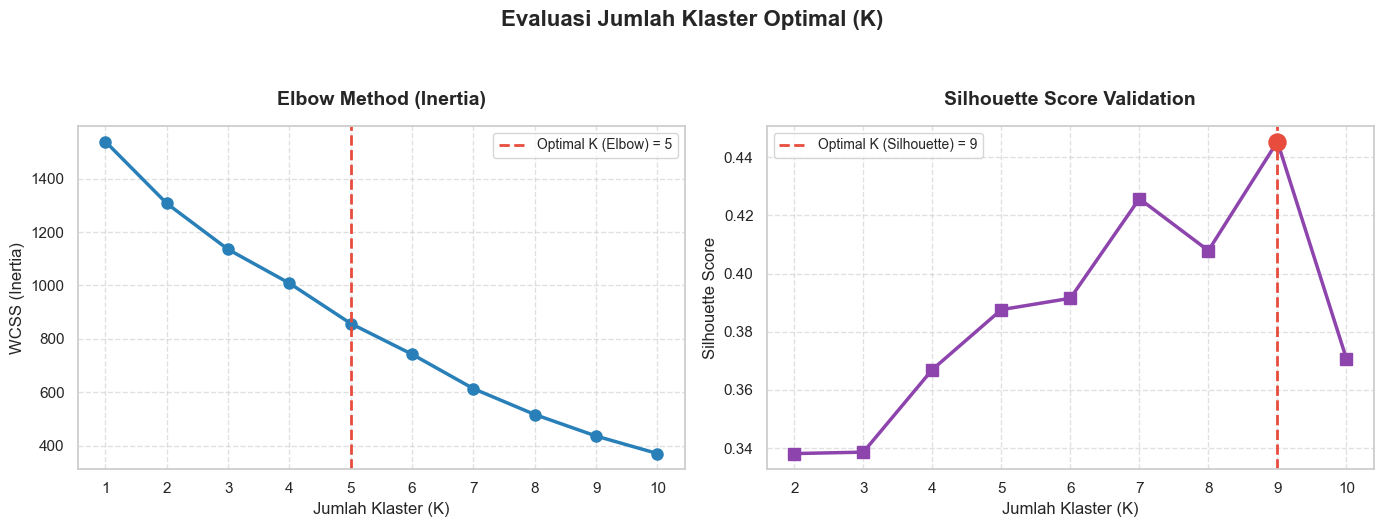

In [22]:
# Asumsi variabel X sudah terdefinisi dari tahap sebelumnya
# X = df_normalized[kolom_qs].values

max_k = 10
K_range = list(range(1, max_k + 1))
K_range_sil = list(range(2, max_k + 1))

wcss = []
sil_scores = []

# ============================================================
# 1. PERHITUNGAN WCSS DAN SILHOUETTE SCORE
# ============================================================
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    wcss.append(kmeans.inertia_)
    
    if k >= 2:
        sil_scores.append(silhouette_score(X, labels))

# ============================================================
# 2. FUNGSI DAN PENCARIAN NILAI K OPTIMAL
# ============================================================
def find_elbow_perpendicular(k_values, inertia_values):
    """Mencari titik siku secara matematis untuk garis panduan di grafik"""
    k_arr, i_arr = np.array(k_values, dtype=float), np.array(inertia_values, dtype=float)
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    i_norm = (i_arr - i_arr.min()) / (i_arr.max() - i_arr.min())
    p1, p2 = np.array([k_norm[0], i_norm[0]]), np.array([k_norm[-1], i_norm[-1]])
    
    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], i_norm[i]])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    return k_values[np.argmax(distances)]

k_opt_elbow = find_elbow_perpendicular(K_range, wcss)
k_opt_sil = K_range_sil[np.argmax(sil_scores)]

# ============================================================
# 3. OUTPUT TEKS DENGAN FLAG REKOMENDASI DAN NOTES
# ============================================================
print("=== DETAIL NILAI WCSS (INERTIA) UNTUK SETIAP NILAI K ===")
print("-" * 50)
for k, w in zip(K_range, wcss):
    flag = " (Rekomendasi)" if k == k_opt_elbow else ""
    print(f"Jumlah Klaster (K = {k:2d}) -> Nilai WCSS: {w:.4f}{flag}")
print("-" * 50)
print("Notes : Penentuan K terbaik berdasarkan WCSS menggunakan Elbow Method")
print("        dipilih pada titik yang memiliki jarak tegak lurus terjauh")
print("        dari garis imajiner antara titik K pertama dan K terakhir.\n")

print("=== DETAIL NILAI SILHOUETTE SCORE UNTUK SETIAP NILAI K ===")
print("-" * 50)
for k, score in zip(K_range_sil, sil_scores):
    flag = " (Rekomendasi)" if k == k_opt_sil else ""
    print(f"Jumlah Klaster (K = {k:2d}) -> Silhouette Score: {score:.4f}{flag}")
print("-" * 50)
print("Notes : Penentuan K terbaik berdasarkan Silhouette Score dipilih")
print("        dari nilai skor tertinggi (paling mendekati 1.0), yang")
print("        menandakan pemisahan antar klaster paling solid dan tegas.\n")

# ============================================================
# 4. VISUALISASI GRAFIK 2 PANEL (ELBOW VS SILHOUETTE)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Elbow Curve ---
ax1 = axes[0]
ax1.plot(K_range, wcss, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
ax1.axvline(x=k_opt_elbow, color='#e74c3c', linestyle='--', linewidth=2, label=f'Optimal K (Elbow) = {k_opt_elbow}')
ax1.set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Jumlah Klaster (K)', fontsize=12)
ax1.set_ylabel('WCSS (Inertia)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(K_range)

# --- Panel 2: Silhouette Score ---
ax2 = axes[1]
ax2.plot(K_range_sil, sil_scores, 's-', color='#8e44ad', linewidth=2.5, markersize=8)
ax2.axvline(x=k_opt_sil, color='#e74c3c', linestyle='--', linewidth=2, label=f'Optimal K (Silhouette) = {k_opt_sil}')
ax2.scatter(k_opt_sil, max(sil_scores), color='#e74c3c', s=150, zorder=5) # Menyorot titik tertinggi
ax2.set_title('Silhouette Score Validation', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Jumlah Klaster (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(K_range_sil)

plt.suptitle('Evaluasi Jumlah Klaster Optimal (K)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()